# BILD 62 FINAL PROJECT

## Importing Important Modules

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import zscore

## Loading the Heart Data Using Pandas

In [3]:
data = pd.read_csv('heart.csv')
data.head(1026)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## Cleaning Data

In [35]:
def cleaning_data(data):
    # remove duplicates
    dup_values = data.duplicated().sum()
    print("Duplicated values: ", dup_values)

    data = data.drop_duplicates()
    
    # remove outliers for resting blood pressure, serum cholesterol, and maximum heart rate using z-score
    columns_to_clean = ['trestbps', 'chol', 'thalach']
    
    # Function to remove outliers using z-score
    def identify_outliers(data, column, threshold = 3):
        z_scores = np.abs(stats.zscore(data[column]))
        return z_scores >= threshold

    # Create a mask for all outliers
    outlier_mask = pd.DataFrame()
    for column in columns_to_clean:
        outlier_mask[column] = identify_outliers(data, column)
    
    # Combine the masks using OR operation
    final_mask = outlier_mask.any(axis=1)
    
    # Remove the outliers
    df_cleaned = data[~final_mask]
    df_cleaned = df_cleaned.drop(columns=['trestbps_zscore'])
    
    return df_cleaned

cleaning_data(data)

Duplicated values:  723


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


## Correlation Matrix of all Factors in Dataset

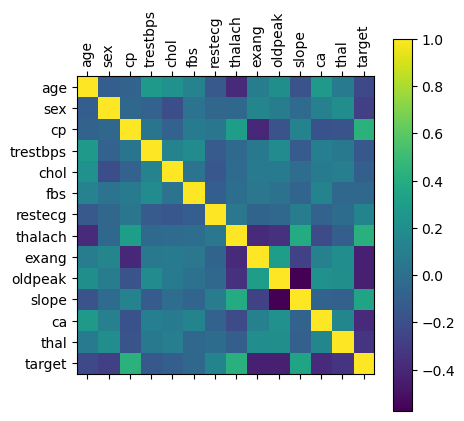

In [5]:
plt.matshow(data.corr())
plt.colorbar()
plt.xticks(ticks = np.arange(14), labels = data.columns, rotation = 90)
plt.yticks(ticks = np.arange(14), labels = data.columns)
plt.show()

## Separating Relevant Datasets

In [6]:
chl_data = data['chol']
#rbp_data = data['trestbps']
mhr_data = data['thalach']
cp_data = data['cp']
hd_incidence = data['target']

## Calculating Correlations between Parameters and Heart Disease Incidence

In [140]:
chl_corr = chl_data.corr(hd_incidence)
rbp_corr = rbp_data.corr(hd_incidence)
mhr_corr = mhr_data.corr(hd_incidence)
cp_corr = cp_data.corr(hd_incidence)
print(chl_corr, rbp_corr, mhr_corr, cp_corr)

-0.09996559423254109 -0.13877173373730106 0.4228954964828711 0.43485425005273737


## Calculating Heart Score

In [170]:
#Heart score is calculated by multiplying given parameters with the correlation and adding them up
def predict_heart_disease(chl, cp, mhr):

    #Ensuring that entered parameters are within the range of dataset
    if chl > np.max(chl_data):
        print("Cholesterol Level is too high to predict with precision")

    elif chl < np.min(chl_data):
        print("Cholesterol Level is too low to predict with precision")

    elif type(cp) != int:
        print("Chest pain input should be integer | 0 = typical angina | 1 = atypical angina | 2 = non-anginal pain | 3 = asymptomatic")

    elif cp > np.max(cp_data):
        print("Chest pain input is out of range")

    elif cp < np.min(cp_data):
        print("Chest pain input is out of range")
    
    elif mhr > np.max(mhr_data):
        print("Maximum heart rate is too high to predict with precision")

    elif mhr < np.min(mhr_data):
        print("Maximum heart rate is too low to predict with precision")

    #Heart score calculation
    else:
        #Multiplying each metric by its correlation and adding them up to give heart score
        heart_score = chl*chl_corr + cp*cp_corr + mhr*mhr_corr

        #Normalizing heart score to obtain probability
        likelihood = 1/(1+math.exp(-heart_score*0.1))
        return 'heart score = ' + str(heart_score), 'likelihood = ' + str(likelihood)

In [172]:
predict_heart_disease(204, 0, 71)

('heart score = 9.632599026845465', 'likelihood = 0.7237740169846832')

In [174]:
print(np.max(chl_data), np.min(chl_data))
print(np.max(rbp_data), np.min(rbp_data))
print(np.max(mhr_data), np.min(mhr_data))

564 126
200 94
202 71
